# 🏠 House Price Prediction – Tabular Regression Showcase

This notebook addresses the **Kaggle House Prices: Advanced Regression Techniques** challenge by applying a **structured modeling pipeline** for tabular regression. Through rigorous **feature engineering**, comparison of **traditional ML models and boosting algorithms**, and a final **ensemble**, the workflow achieves strong predictive performance with generalizability in mind.



## Project Highlights

- **Dataset**: Ames Housing Dataset from [Kaggle](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
- **Target**: Predicting `SalePrice` using both numerical and categorical features


## Key Workflow Components

- **Exploratory Data Analysis & Feature Engineering**
  - Domain-informed transformations (area, quality, age, ratios)
  - Encapsulated processing pipeline for reusable preprocessing
- **Modeling and Evaluation**
  - Baselines: Decision Tree, Random Forest, Lasso, Neural Net
  - Boosting: Gradient Boosting, XGBoost, LightGBM, CatBoost
  - Final strategy: **Ensemble of XGBoost + CatBoost**
- **Evaluation Metric**
  - Root Mean Squared Log Error (rMSLE) on log-transformed target
  - Train/Validation split with reproducible random seed
  - Final public Kaggle score: **Top ~800 (rMSE ≈ 0.1186)**


> 🎯 This project demonstrates applied tabular modeling with real-world constraints, feature logic, and model interpretability — core traits of production-ready machine learning pipelines.

In [1]:
from fastai.tabular.all import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from dtreeviz.trees import *
pd.options.display.max_rows = 20
pd.options.display.max_columns = 8
import warnings
warnings.filterwarnings('ignore')

# Dataset
- Kaggle competition: House Prices - Advanced Regression Techniques
    - [Download](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

In [2]:
path = Path("/Users/applewang/Desktop/Study_Materials_2023_2025/fastai_course/my-practice/house-prices-advanced-regression-techniques")
Path.BASE_PATH = path
path.ls()

(#6) [Path('my_submission_kaggle'),Path('.DS_Store'),Path('test.csv'),Path('data_description.txt'),Path('train.csv'),Path('sample_submission.csv')]

In [3]:
train_df = pd.read_csv(path/'train.csv', low_memory=False)
df = train_df.copy()
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,...,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,...,2008,WD,Normal,208500
1,2,20,RL,80.0,...,2007,WD,Normal,181500
2,3,60,RL,68.0,...,2008,WD,Normal,223500


# EDA & Preprocess

In [4]:
#check all features how many missing values - drop/fillna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
#MoSold, YrSold change type to float64, otherwise will be labeled as categorical features
df['MoSold'] = df['MoSold'].astype('float64')
df['YrSold'] = df['YrSold'].astype('float64')

In [6]:
#Some features need to fill missing values
features = list(df.columns)
for i in features:
    if df[i].isnull().sum() >0:
        if df[i].dtype == 'object': df[i] = df[i].fillna('None') #features may have such conditions instead of missing records
        else: df[i] = df[i].fillna(df[i].median())

## Process-in-one function

After extensive **EDA exploration** and studying multiple top-performing Kaggle solutions, I consolidated the insights into a single processing function: `process_features`. This function encapsulates all **domain-relevant feature transformations** discovered through iterative hypothesis testing, public solution review, and performance validation.

This unified pipeline improves modeling consistency and ensures fair evaluation across all models used in this notebook (tree-based, boosting, and neural nets). It’s designed for **reusability, scalability, and interpretability** — vital traits for tabular ML pipelines in real-world applications.

> All transformations were validated against downstream model performance and feature importance diagnostics.

In [4]:
def process_features(df, is_train=True):
    #is_train help to processe train/valid set seperately
    
    df = df.copy()
    
    # Area features
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
    df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['Has2ndFlr'] = (df['2ndFlrSF'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['TotalArea'] = df['TotalSF'] + df['GarageArea'] + df['TotalPorchSF']
    df['LivingArea'] = df['GrLivArea'] + df['TotalBsmtSF']
    
    # Quality features
    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
    df['ExterQual_num'] = df['ExterQual'].map(qual_map)
    df['ExterCond_num'] = df['ExterCond'].map(qual_map)
    df['BsmtQual_num'] = df['BsmtQual'].map(qual_map)
    df['BsmtCond_num'] = df['BsmtCond'].map(qual_map)
    df['HeatingQC_num'] = df['HeatingQC'].map(qual_map)
    df['KitchenQual_num'] = df['KitchenQual'].map(qual_map)
    df['FireplaceQu_num'] = df['FireplaceQu'].map(qual_map)
    df['GarageQual_num'] = df['GarageQual'].map(qual_map)
    df['GarageCond_num'] = df['GarageCond'].map(qual_map)
    
    # Grade features
    df['OverallGrade'] = df['OverallQual'] * df['OverallCond']
    df['ExterGrade'] = df['ExterQual_num'] * df['ExterCond_num']
    df['GarageGrade'] = df['GarageQual_num'] * df['GarageCond_num']
    df['TotalQual'] = df['OverallQual'] + df['ExterQual_num'] + df['BsmtQual_num'] + df['KitchenQual_num']
    
    # Age features
    df['Age'] = df['YrSold'] - df['YearBuilt']
    df['IsNew'] = (df['Age'] <= 2).astype(int)
    df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
    df['RecentRemodel'] = (df['YearsSinceRemodel'] <= 2).astype(int)
    df['AgeRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['IsNewRemod'] = (df['AgeRemod'] <= 2).astype(int)
    
    # Garage features
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
    df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
    
    # Categorical types
    df['MSSubClass'] = df['MSSubClass'].astype(str)
    df['YrSold'] = df['YrSold'].astype(str)
    df['MoSold'] = df['MoSold'].astype(str)
    
    # Missing values
    df['LotFrontage'] = df.groupby(['Neighborhood', 'LotArea'])['LotFrontage'].transform(
        lambda x: x.fillna(x.median()) if not x.isnull().all() else x.fillna(0)
    )

    features = list(df.columns)
    for i in features:
        if df[i].isnull().sum() >0:
            if df[i].dtype == 'object': df[i] = df[i].fillna('None') #features may have such conditions instead of missing records
            else: df[i] = df[i].fillna(df[i].median())
    
    # Create ration features
    df['LivLotRatio'] = df['GrLivArea'] / df['LotArea']
    df['Density'] = df['GrLivArea'] / (df['LotArea'] + 1)
    df['PricePerTotalSF'] = df['TotalSF'] / (df['LotArea'] + 1)
    df['PricePerLivArea'] = df['LivingArea'] / (df['LotArea'] + 1)
    
    # Create Neighborhood Bins
    df['NeighborhoodBin'] = pd.qcut(df.groupby('Neighborhood')['LotArea'].transform('median'), 5, labels=False)
    
    if is_train:
        # Saleprice transform
        df['SalePrice'] = np.log1p(df['SalePrice'])
        df['Price_per_SF'] = df['SalePrice'] / df['TotalSF']
        df['Price_per_Room'] = df['SalePrice'] / df['TotRmsAbvGrd']
        df['Price_per_Bath'] = df['SalePrice'] / df['TotalBathrooms']
    
    return df


In [5]:
df = process_features(df, is_train=True)

## Handle outliers

In [6]:
def handle_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return df

In [7]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df = handle_outliers(df, numeric_cols)

## Dataloaders

In [8]:
splits = RandomSplitter(valid_pct=0.2, seed=20)(range_of(df))

In [9]:
cont_names = [
        'Age', 'TotalSF', 'TotalBathrooms', 'TotalPorchSF',
        'OverallGrade', 'YearsSinceRemodel', 'ExterQual_num',
        'KitchenQual_num', 'GrLivArea', 'LotArea',
        'GarageAge', 'LivLotRatio', 'Density',
        'BsmtQual_num', 'FireplaceQu_num', 'GarageQual_num']
    
cat_names = [
        'MSSubClass', 'MSZoning', 'Street', 'LotShape',
        'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
        'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
        'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
        'Exterior2nd', 'Foundation', 'Heating', 'CentralAir',
        'Electrical', 'Functional', 'GarageType', 'PavedDrive',
        'SaleType', 'SaleCondition', 'YrSold', 'MoSold']    

In [11]:
train_tab = TabularPandas(df,
                      procs=[FillMissing, Categorify,Normalize],
                      cat_names=cat_names,
                      cont_names=cont_names,
                      y_names='SalePrice',
                      splits=splits)

trn_dls = train_tab.dataloaders(bs=32)

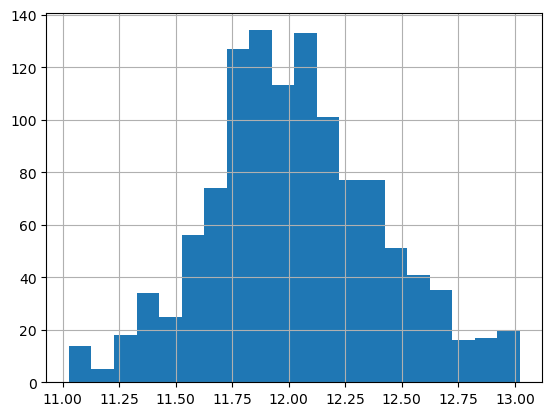

In [13]:
trn_dls.y.hist(bins=20);

In [14]:
np.expm1(trn_dls.y[:2]) #np.log1p reverse to get the 'Saleprice' for final outputs

1061    80999.976562
307     89500.007812
Name: SalePrice, dtype: float32

In [33]:
train_xs = trn_dls.train.xs
train_y = trn_dls.train.y
valid_xs = trn_dls.valid.xs
valid_y = trn_dls.valid.y

# Metrics RMSE

In [15]:
def r_mse(pred,y): return round(math.sqrt(((pred-y)**2).mean()), 6)
def m_rmse(m, xs, y): return r_mse(m.predict(xs), y)

# Decision Tree

In [34]:
m = DecisionTreeRegressor(max_leaf_nodes=5)
m.fit(train_xs,train_y)

DecisionTreeRegressor(max_leaf_nodes=5)

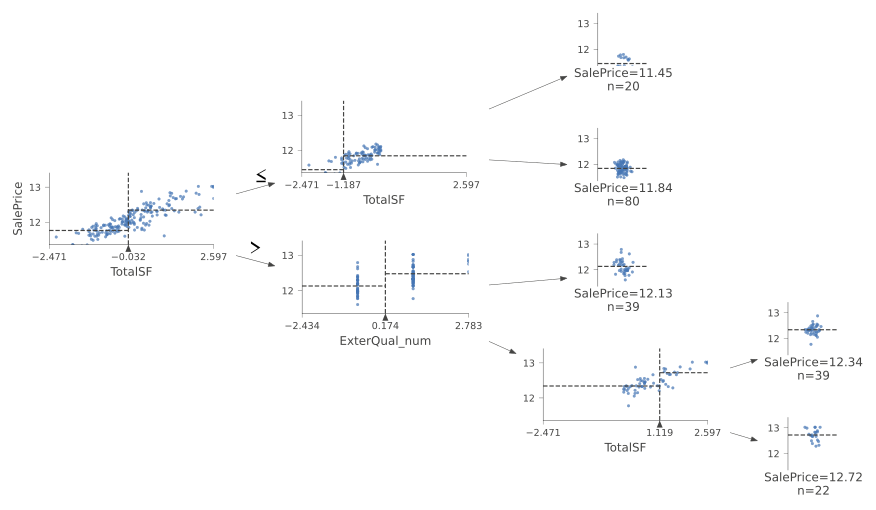

In [35]:
samp_idx = np.random.permutation(len(train_y))[:200]
dep_var = 'SalePrice'
dtreeviz(m, train_xs.iloc[samp_idx], train_y.iloc[samp_idx], train_xs.columns, dep_var,
        fontname='DejaVu Sans', scale=1.6, label_fontsize=10,
        orientation='LR')

## Baseline rMSE

In [36]:
m = DecisionTreeRegressor(max_depth=3)
m.fit(train_xs, train_y)
m_rmse(m,train_xs,train_y), m_rmse(m, valid_xs, valid_y)

(0.191908, 0.215937)

In [37]:
m.get_n_leaves()

8

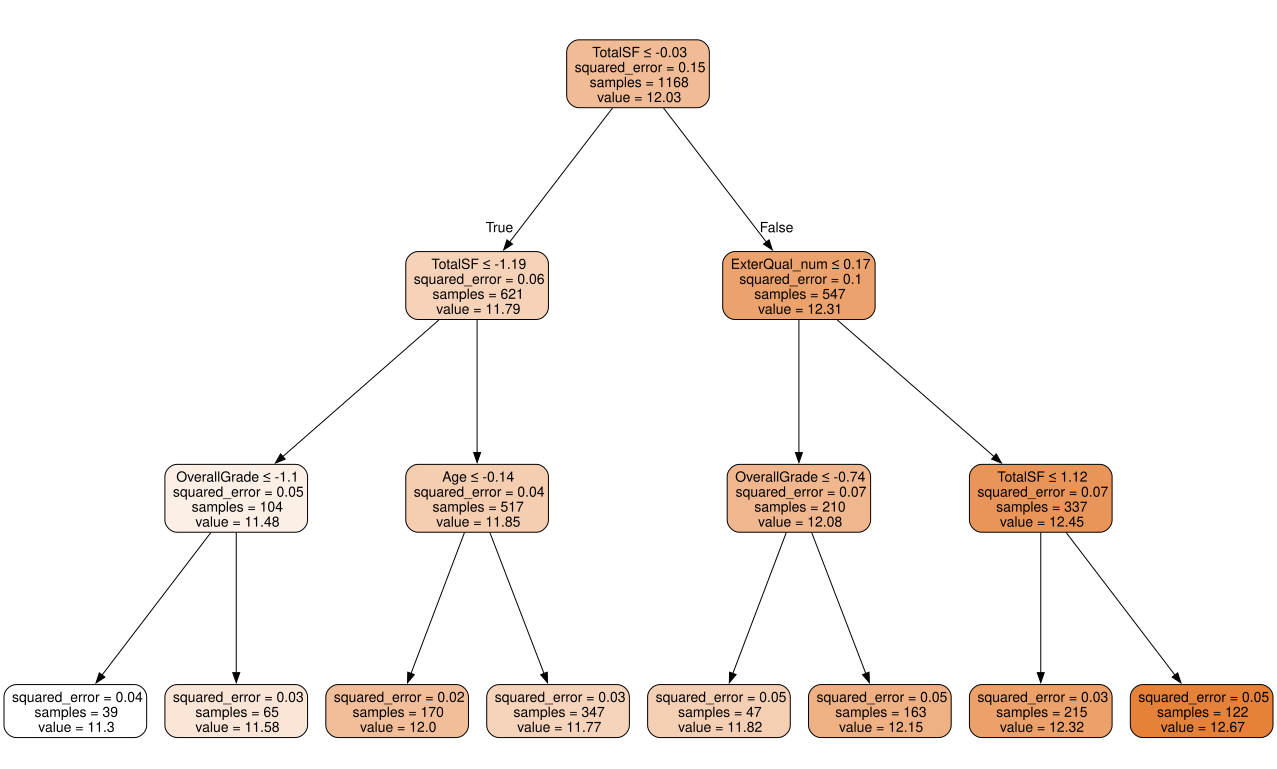

In [38]:
from sklearn.tree import export_graphviz

def draw_tree(t, df, size=10, ratio=0.6, precision=0, **kwargs):
    s=export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                      special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))
draw_tree(m, train_xs, size=20,leaves_parallel=True, precision=2)

# Random forest

In [39]:
def rf(xs, y, n_estimators=50, max_samples=1000,max_depth=16, 
       min_samples_leaf=25, max_features=0.5, **kwargs):
    return RandomForestRegressor(n_estimators=n_estimators, n_jobs=-1, 
                                 max_samples=max_samples, 
                                 min_samples_leaf=min_samples_leaf,max_depth=max_depth,
                                max_features=max_features,oob_score=True).fit(xs,y)

In [40]:
m2 = rf(train_xs, train_y)
m_rmse(m2, train_xs, train_y), m_rmse(m2, valid_xs, valid_y)

(0.138102, 0.151848)

In [41]:
r_mse(m2.oob_prediction_, train_y)

0.151458

Improving! -> Check the tree variances whether in wide range. (Not vary)

In [42]:
preds = np.stack([t.predict(valid_xs) for t in m2.estimators_])
preds.std(0)[:6]

array([0.08786204, 0.12665611, 0.1153246 , 0.09760681, 0.08586664,
       0.20493579])

In [27]:
fi = rf_feat_importance(trn_dls.xs, m2)
to_keep = fi[fi.imp>0.01]
len(to_keep)

11

In [28]:
xs_imp = trn_dls.xs[to_keep]
valid_xs_imp = trn_dls.valid.xs[to_keep]

In [29]:
m2_1 = rf(xs_imp,trn_dls.y)

In [30]:
m_rmse(m2_1, xs_imp,trn_dls.y), m_rmse(m2_1, valid_xs_imp, trn_dls.valid.y)

(0.384502, 0.396398)

After removing low important features, rMSE surprisely increases! Due to the training set is quite small, some features may have very low imp score but relating to other important features I guess. So removal of low importance features is not a good solution here.

# Boosting Models

**Why Boosting?**

Boosting builds models sequentially, each one trying to correct the mistakes of the previous. Compared to bagging-based methods like Random Forests, boosting (e.g., XGBoost, LightGBM, CatBoost) often yields better generalization in structured regression tasks, especially when tuned properly.

I chose to include multiple boosting algorithms in this notebook to compare their performance and robustness under the same preprocessing setup.

## GradientBoostingRegressor
Scikit-learn’s GradientBoostingRegressor is a classic implementation of gradient boosting decision trees. While it lacks the advanced speed and regularization optimizations of newer libraries like XGBoost or LightGBM, it remains a reliable and interpretable baseline for smaller datasets.

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

In [48]:
m3_gbr = GradientBoostingRegressor().fit(train_xs,train_y)

In [49]:
m_rmse(m3_gbr, train_xs, train_y), m_rmse(m3_gbr, valid_xs, valid_y)

(0.081017, 0.125113)

Quite better!

## Xgboost
XGBoost (Extreme Gradient Boosting) is a highly optimized and regularized boosting algorithm. It introduces advanced features like tree pruning, sparsity awareness, and efficient parallelism. Known for its excellent performance in many Kaggle competitions, it is a solid choice for large tabular datasets.

In [46]:
from xgboost import XGBRegressor

In [50]:
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 5,
    'learning_rate': 0.01,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'n_estimators': 3000,
    'early_stopping_rounds': 100
}
m3_xgb = XGBRegressor(**xgb_params)
m3_xgb.fit(
            train_xs, train_y,
            eval_set=[(valid_xs, valid_y)],
            verbose=100
        )

[0]	validation_0-rmse:0.39333
[100]	validation_0-rmse:0.20463
[200]	validation_0-rmse:0.14555
[300]	validation_0-rmse:0.12910
[400]	validation_0-rmse:0.12421
[500]	validation_0-rmse:0.12262
[600]	validation_0-rmse:0.12218
[700]	validation_0-rmse:0.12203
[800]	validation_0-rmse:0.12187
[900]	validation_0-rmse:0.12178
[1000]	validation_0-rmse:0.12169
[1100]	validation_0-rmse:0.12166
[1200]	validation_0-rmse:0.12162
[1300]	validation_0-rmse:0.12155
[1400]	validation_0-rmse:0.12152
[1500]	validation_0-rmse:0.12151
[1600]	validation_0-rmse:0.12146
[1700]	validation_0-rmse:0.12144
[1800]	validation_0-rmse:0.12142
[1900]	validation_0-rmse:0.12141
[2000]	validation_0-rmse:0.12140
[2100]	validation_0-rmse:0.12140
[2200]	validation_0-rmse:0.12138
[2300]	validation_0-rmse:0.12132
[2400]	validation_0-rmse:0.12133
[2407]	validation_0-rmse:0.12133


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
m_rmse(m3_xgb, train_xs, train_y), m_rmse(m3_xgb, valid_xs, valid_y)

(0.087773, 0.121323)

## LightGBM
LightGBM is a gradient boosting framework by Microsoft that uses histogram-based algorithms and leaf-wise tree growth, which makes it significantly faster and more memory-efficient than XGBoost on large datasets. It also handles categorical features natively and works well on high-dimensional data.

In [52]:
import lightgbm

In [53]:
m3_light = lightgbm.LGBMRegressor(max_depth=2, n_estimators=300).fit(train_xs,train_y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1912
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 39
[LightGBM] [Info] Start training from score 12.029207
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [55]:
m_rmse(m3_light, train_xs, train_y), m_rmse(m3_light, valid_xs, valid_y)

(0.088887, 0.118628)

## CatBoost
CatBoost (by Yandex) is specifically designed to handle categorical variables without preprocessing. It uses an ordered boosting technique to reduce overfitting and performs well out-of-the-box with minimal tuning. It is often the best choice when working with many categorical features or limited data.

In [59]:
from catboost import CatBoostRegressor

In [60]:
cat_params = {
    'objective': 'RMSE',
    'iterations': 3000,
    'learning_rate': 0.01,
    'depth': 6,
    'l2_leaf_reg': 3,
    'random_strength': 0.1,
    'min_data_in_leaf': 5,
    'bagging_temperature': 1,
    'early_stopping_rounds': 100
}
m3_cat = CatBoostRegressor(**cat_params)
m3_cat.fit(
            train_xs, train_y,
            eval_set=[(valid_xs, valid_y)],
            verbose=False
        )

In [61]:
m_rmse(m3_cat, train_xs,train_y), m_rmse(m3_cat, valid_xs, valid_y)

(0.063522, 0.115959)

# Lasso regression
Lasso Regression (Least Absolute Shrinkage and Selection Operator) is a linear model with L1 regularization, which encourages sparsity in the learned coefficients. This means it can automatically perform feature selection by driving some coefficients to zero. 

While less powerful than tree-based models for capturing nonlinear patterns, Lasso is interpretable, computationally efficient, and effective when many features are potentially irrelevant or correlated.

In [56]:
from sklearn.linear_model import LassoCV

In [57]:
m3_lasso = LassoCV(alphas = [1, 0.1, 0.001, 0.0005]).fit(train_xs,train_y)

In [58]:
m_rmse(m3_lasso, train_xs, train_y), m_rmse(m3_lasso, valid_xs, valid_y)

(0.123688, 0.127117)

# Nerual network using Fastai

In [63]:
trn_dls.y.min(), trn_dls.y.max()

(11.027159, 13.021683)

In [64]:
m4_nn = tabular_learner(trn_dls, y_range=(11, 14), layers=[200,40], metrics=[rmse], loss_func=MSELossFlat())

SuggestedLRs(valley=0.007585775572806597)

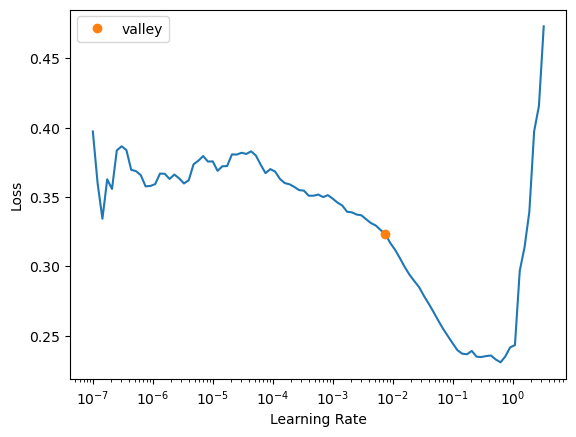

In [65]:
m4_nn.lr_find()

In [67]:
m4_nn.fit_one_cycle(30, 0.02)

epoch,train_loss,valid_loss,_rmse,time
0,0.228269,0.169207,0.411348,00:01
1,0.142304,0.034742,0.186392,00:00
2,0.078719,0.021145,0.145414,00:00
3,0.050007,0.054977,0.234471,00:00
4,0.051081,0.237476,0.487315,00:00
5,0.040497,0.039814,0.199534,00:00
6,0.031508,0.022521,0.150070,00:00
7,0.027366,0.022989,0.151620,00:00
8,0.024711,0.027815,0.166779,00:00
9,0.025893,0.018005,0.134183,00:00


In [68]:
nn_preds, nn_targs = m4_nn.get_preds()
r_mse(nn_preds, nn_targs)

0.125743

# Ensemble 
After several experiments in ensemble different models, the final combination is **XGBoost & CatBoost** for highest score in kaggle competition leaderboard.

In [69]:
pred_xgb = m3_xgb.predict(valid_xs)

In [70]:
pred_cat = m3_cat.predict(valid_xs)

In [71]:
pred_en = (0.7*pred_xgb + 0.3*pred_cat)

In [72]:
r_mse(pred_en, valid_y)

0.118686

# Model Performance Comparison (rMSE)

| Model                          | rMSE (Train) | rMSE (Valid) | Notes                                                   |
|-------------------------------|--------------|--------------|----------------------------------------------------------|
| Decision Tree Regression       | 0.191908     | 0.215937     | Baseline model; slight overfitting                      |
| Random Forest                  | 0.138102     | 0.151848     | Improved; less variance than decision tree              |
| Gradient Boosting Regressor   | 0.081017     | 0.125113     | Much improved; stronger performance                     |
| XGBoost                        | 0.087773     | 0.121323     | Further improved; solid boosting model                  |
| LightGBM                       | 0.088887     | 0.118628     | Slightly better than XGBoost                            |
| Lasso Regression               | 0.123688     | 0.127117     | Just better than RF; worse than boosting models         |
| CatBoost                       | 0.063522  ✅   | 0.115959  ✅   | Best among boosting models; strong regularization       |
| Neural Network (fastai)       | 0.125743     | -            | Similar to Lasso; not competitive with boosting models  |
| Ensemble (XGBoost + CatBoost) | -            | 0.118686  ⭐️   | Best Kaggle score (0.12735 #865 in leaderboard)   |

# Kaggle Submission

In [73]:
test_df = pd.read_csv(path/'test.csv', low_memory=False)
tdf = test_df.copy()
tdf.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,...,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,...,6,2010,WD,Normal
1,1462,20,RL,81.0,...,6,2010,WD,Normal


## Process Test data

In [74]:
tdf = process_features(tdf, is_train=False)

numeric_cols = tdf.select_dtypes(include=['float64', 'int64']).columns
tdf = handle_outliers(tdf, numeric_cols)

In [75]:
test_dls = TabularPandas(tdf, 
                         procs=[FillMissing, Categorify, Normalize],
                        cat_names=cat_names,
                         cont_names=cont_names,
                         y_names=None,
                         splits=None).dataloaders(bs=32)

test_xs = test_dls.train.xs

## Predictions Submit

In [76]:
preds_xgb = m3_xgb.predict(test_xs)
preds_cat = m3_cat.predict(test_xs)

In [77]:
preds_log = (0.7*preds_xgb + 0.3*preds_cat)
preds_final = np.expm1(preds_log)
preds_final

array([125690.29923286, 170381.21921354, 165553.63862524, ...,
       142948.47219086, 127734.31420438, 194404.50224042])

In [78]:
preds_df = pd.DataFrame(preds_final, columns=['SalePrice'])

In [79]:
preds_df['Id'] = test_df['Id']

In [80]:
submission = preds_df[['Id', 'SalePrice']]
submission

,Id,SalePrice
0,1461,125690.299233
1,1462,170381.219214
2,1463,165553.638625
3,1464,175724.870739
4,1465,173067.697832
...,...,...
1454,2915,99242.769095
1455,2916,91974.558852
1456,2917,142948.472191
1457,2918,127734.314204


In [ ]:
submission.to_csv('houseprice_nn_env.csv', index=False) 

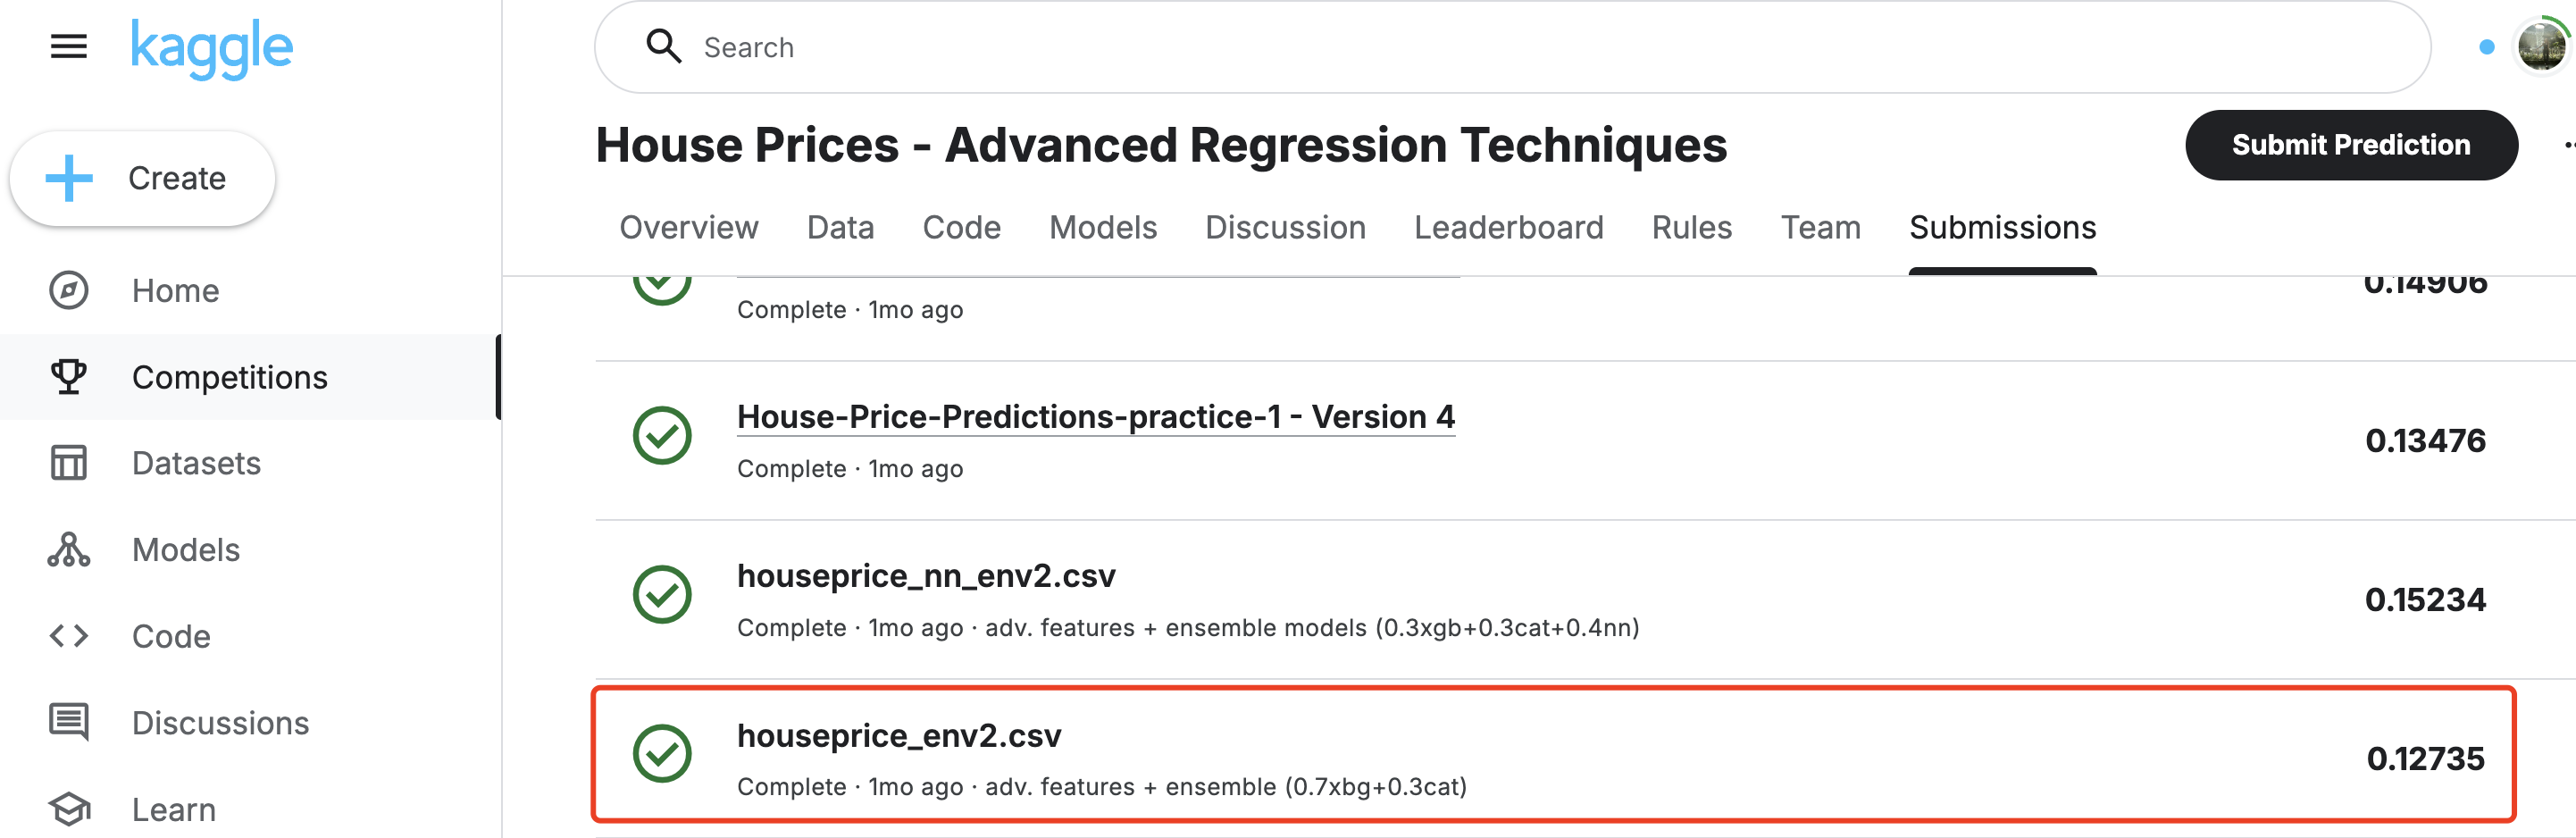

Push notebook to kaggle:
```python
from fastkaggle import *

push_notebook('apple9855wang', 'House-Price-Predictions-practice-1',
             title='House-Price-Predictions-practice-1',
             file='0061_practice_houseprices.ipynb',
             competition='house-prices-advanced-regression-techniques'
             )

# 🎯 Conclusion: Boosting Wins – Why and When

In this notebook, we explored **eight regression models** on the California House Prices dataset:

| Model Type          | Technique         | Notes                            |
|---------------------|-------------------|----------------------------------|
| Tree-based          | Decision Tree     | Simple baseline, overfitting     |
| Ensemble            | Random Forest     | Stronger, still overfit-prone    |
| Regularized Linear  | Lasso             | Competitive, interpretable, solve overfitting|
| **Boosting**        | GBR / XGBoost / LightGBM /CatBoost | **Top performing**         |
| Neural Network      | MLP (Fastai)      | Lower performance |
| **Ensemble**        | XGBoost + CatBoost | **Best Kaggle Score**            |



## Boosting Outperforms Here

**Boosting models excel on structured/tabular data** with:
- High-cardinality categorical features (CatBoost handles them natively)
- Missing data (no need for manual imputation)
- Complex nonlinear interactions
- Limited training data where deep NNs struggle to generalize

**Neural Networks underperformed** due to:
- Sensitivity to small data and overfitting
- Lack of strong feature hierarchies or spatial/temporal structure
- High dependency on careful hyperparameter tuning and regularization


## Ensembling Improves Generalization

Although the ensemble had slightly higher `rMSE` on validation set than individual boosters, it **achieved the best Kaggle leaderboard score**.

**Reason**: Ensembling combines the strengths of multiple learners, which:
- Reduces **model variance**
- Compensates for individual **biases**
- Improves **robustness on unseen test data**

---

🎯 This notebook demonstrates practical **deep learning engineering workflows**, balancing:
- Feature engineering intuition
- Model selection grounded in data type
- Performance diagnostics with real-world considerations

> For real-world tabular regression problems:
> - ✅ Start with **boosting models** (LightGBM, XGBoost, CatBoost)
> - 🎯 Consider **ensembling** to maximize test-time robustness
> - 🤖 Use **neural networks** only when dataset is large, complex, and embeddings are meaningful
